<a href="https://colab.research.google.com/github/TerteryanTatev/Systems-Modeling-and-Simulation/blob/main/Markov-Chains-Hotel-Simulation/markov_chain_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

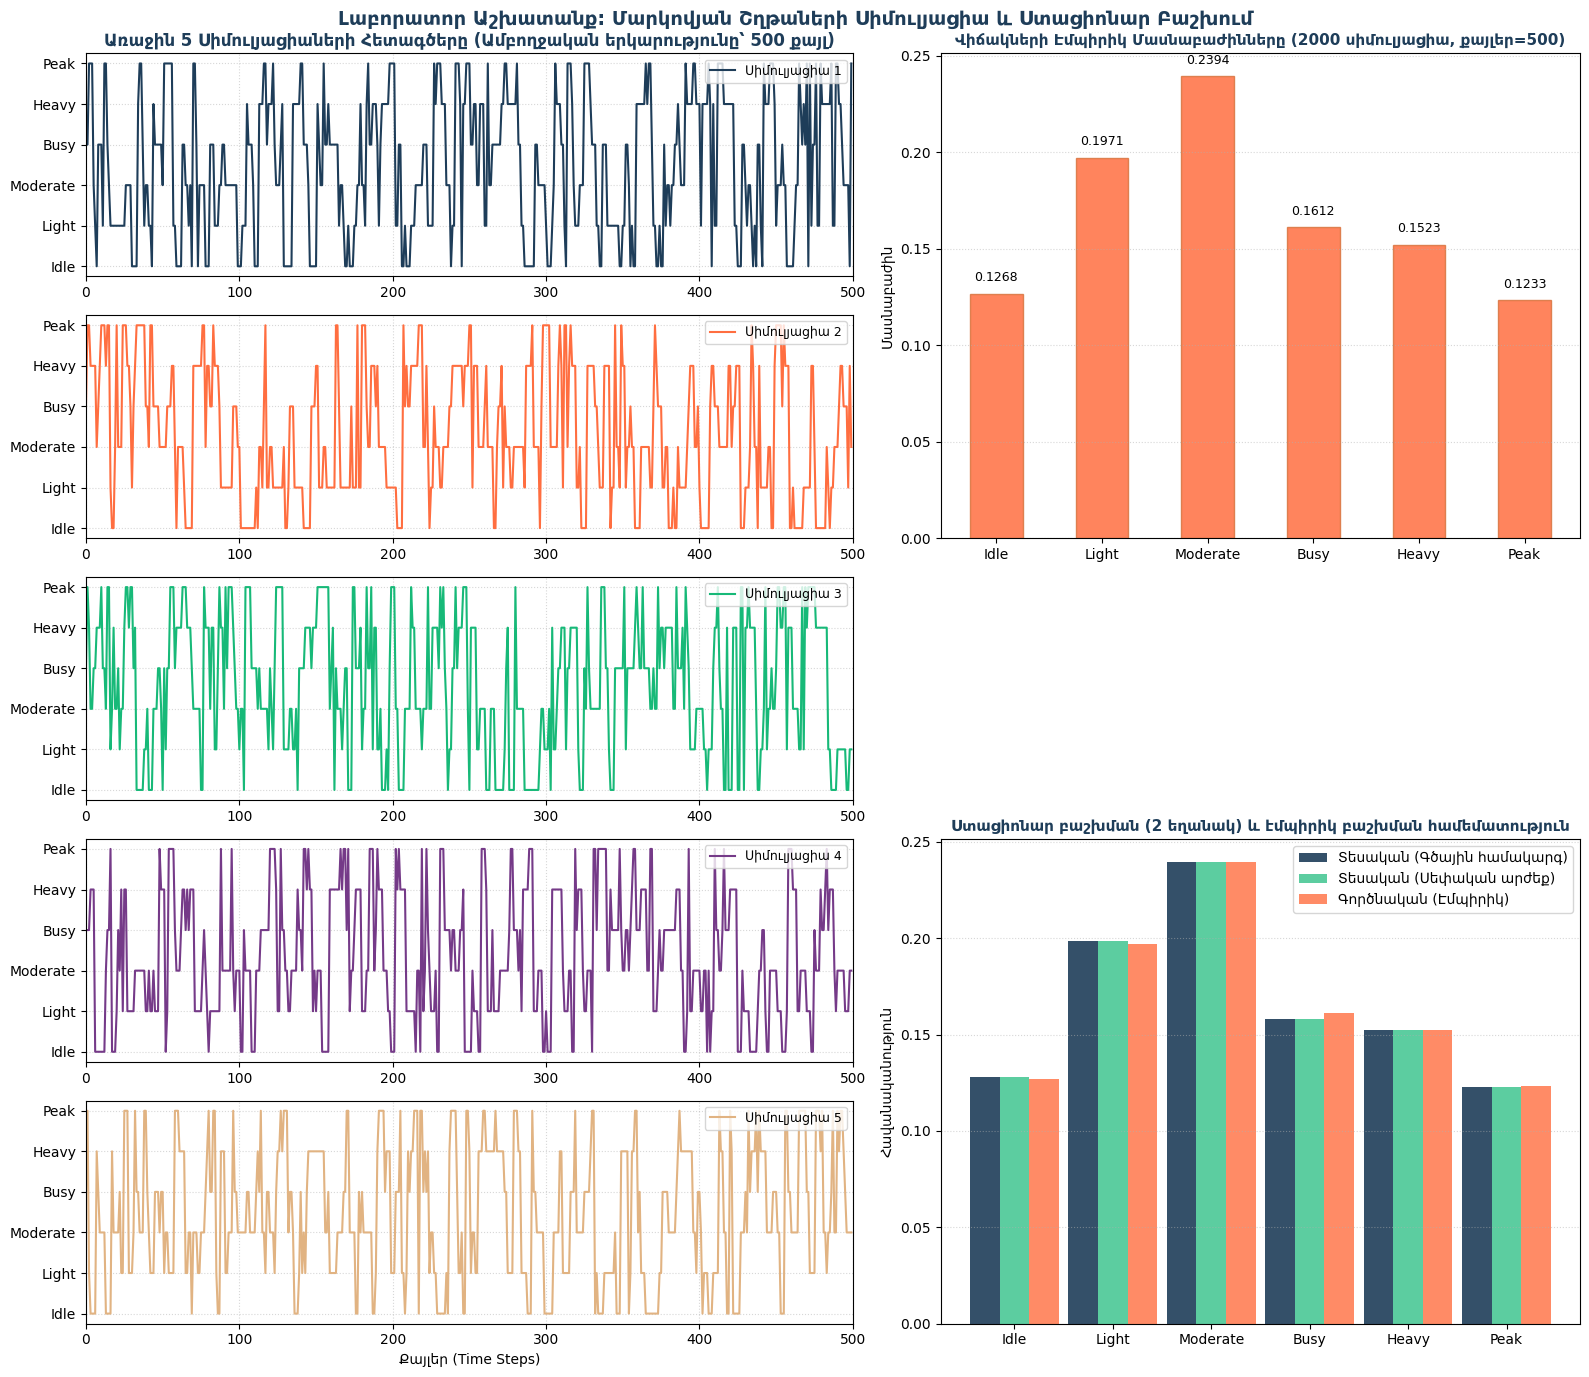


--- ՍՏՈՒԳՈՂ ԱՂՅՈՒՍԱԿ ---
Idle     | Սեփական արժեք: 0.1282 | Գծային համակարգ: 0.1282 | Էմպիրիկ: 0.1268
Light    | Սեփական արժեք: 0.1984 | Գծային համակարգ: 0.1984 | Էմպիրիկ: 0.1971
Moderate | Սեփական արժեք: 0.2396 | Գծային համակարգ: 0.2396 | Էմպիրիկ: 0.2394
Busy     | Սեփական արժեք: 0.1581 | Գծային համակարգ: 0.1581 | Էմպիրիկ: 0.1612
Heavy    | Սեփական արժեք: 0.1526 | Գծային համակարգ: 0.1526 | Էմպիրիկ: 0.1523
Peak     | Սեփական արժեք: 0.1230 | Գծային համակարգ: 0.1230 | Էմպիրիկ: 0.1233


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

states = ['Idle', 'Light', 'Moderate', 'Busy', 'Heavy', 'Peak']
n_states = len(states)

P = np.array([
    [0.62, 0.13, 0.07, 0.08, 0.06, 0.04], # Idle
    [0.09, 0.58, 0.17, 0.06, 0.04, 0.06], # Light
    [0.08, 0.11, 0.62, 0.11, 0.03, 0.05], # Moderate
    [0.01, 0.10, 0.18, 0.47, 0.15, 0.09], # Busy
    [0.05, 0.08, 0.09, 0.07, 0.55, 0.16], # Heavy
    [0.02, 0.10, 0.05, 0.20, 0.18, 0.45]  # Peak
])

start_state_idx = states.index('Busy')
sim_length = 500
n_simulations = 2000

np.random.seed(42)
all_simulations = np.zeros((n_simulations, sim_length), dtype=int)

for sim in range(n_simulations):
    current_state = start_state_idx
    all_simulations[sim, 0] = current_state
    for step in range(1, sim_length):
        current_state = np.random.choice(n_states, p=P[current_state])
        all_simulations[sim, step] = current_state

state_counts = np.bincount(all_simulations.flatten(), minlength=n_states)
empirical_proportions = state_counts / all_simulations.size


eigenvalues, eigenvectors = la.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
stationary_eigen = np.real(eigenvectors[:, idx])
stationary_eigen /= np.sum(stationary_eigen)

A = P.T - np.eye(n_states)
A[-1, :] = 1
b = np.zeros(n_states)
b[-1] = 1
stationary_linear = la.solve(A, b)

fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(5, 2, width_ratios=[1.2, 1])

colors = ['#1e3d59', '#ff6e40', '#17b978', '#753a88', '#e1b382']

for i in range(5):
    ax = fig.add_subplot(gs[i, 0])
    ax.plot(all_simulations[i, :], color=colors[i], linewidth=1.5, label=f'Սիմուլյացիա {i+1}')
    ax.set_yticks(range(n_states))
    ax.set_yticklabels(states)
    ax.set_xlim(0, sim_length)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9)
    if i == 0:
        ax.set_title('Առաջին 5 Սիմուլյացիաների Հետագծերը (Ամբողջական երկարությունը՝ 500 քայլ)', fontsize=12, fontweight='bold', color='#1e3d59')
    if i == 4:
        ax.set_xlabel('Քայլեր (Time Steps)', fontsize=10)

ax_emp = fig.add_subplot(gs[0:2, 1])
bars = ax_emp.bar(states, empirical_proportions, color='#ff6e40', alpha=0.85, edgecolor='#d9743f', width=0.5)
ax_emp.set_title('Վիճակների Էմպիրիկ Մասնաբաժինները (2000 սիմուլյացիա, քայլեր=500)', fontsize=11, fontweight='bold', color='#1e3d59')
ax_emp.set_ylabel('Մասնաբաժին')
ax_emp.grid(True, linestyle=':', alpha=0.5, axis='y')
for bar in bars:
    yval = bar.get_height()
    ax_emp.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontsize=9)

ax_comp = fig.add_subplot(gs[3:5, 1])
x = np.arange(n_states)
width = 0.3
ax_comp.bar(x - width, stationary_linear, width, label='Տեսական (Գծային համակարգ)', color='#1e3d59', alpha=0.9)
ax_comp.bar(x, stationary_eigen, width, label='Տեսական (Սեփական արժեք)', color='#17b978', alpha=0.7)
ax_comp.bar(x + width, empirical_proportions, width, label='Գործնական (Էմպիրիկ)', color='#ff6e40', alpha=0.8)
ax_comp.set_xticks(x)
ax_comp.set_xticklabels(states)
ax_comp.set_title('Ստացիոնար բաշխման (2 եղանակ) և էմպիրիկ բաշխման համեմատություն', fontsize=11, fontweight='bold', color='#1e3d59')
ax_comp.set_ylabel('Հավանականություն')
ax_comp.grid(True, linestyle=':', alpha=0.5, axis='y')
ax_comp.legend(loc='upper right')

plt.suptitle('Լաբորատոր Աշխատանք: Մարկովյան Շղթաների Սիմուլյացիա և Ստացիոնար Բաշխում', fontsize=14, fontweight='bold', color='#1e3d59', y=0.98)
plt.tight_layout()
plt.show()

print("\n--- ՍՏՈՒԳՈՂ ԱՂՅՈՒՍԱԿ ---")
for i, state in enumerate(states):
    print(f"{state:8s} | Սեփական արժեք: {stationary_eigen[i]:.4f} | Գծային համակարգ: {stationary_linear[i]:.4f} | Էմպիրիկ: {empirical_proportions[i]:.4f}")